# Notebook 10 — Age Bias Analysis

Two-part audit of the car price prediction pipeline:

**Part A — Cleaning Audit**: Does brand-level IQR outlier removal disproportionately eliminate old or very new cars?

**Part B — Model Error by Year**: Does the `lean_full` quantile model have higher prediction error for oldest or newest cars in the test set?

Primary metric: `pct_err_over_year_median = mean(|actual − pred|) / median(actual prices in that year) × 100`

In [1]:
import os
import sys
import json
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# ── Project root & source path ────────────────────────────────────────────────
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

import data_processing
from config import DATA_PATH
from features.feature_engineering import CarPriceFeatureEngineer
from data_processing import CarDataProcessor

# ── Key constants (must match notebook 09 exactly) ────────────────────────────
CURRENT_YEAR      = 2025
TRAIN_TEST_SEED   = 42
IQR_MULTIPLIER    = 1.5
ARTIFACTS_DIR     = project_root / "output" / "mlflow_artifacts"
data_dir          = Path(os.path.join(DATA_PATH, "le_boncoin_13_oct_2025"))

# ── Age buckets for grouping car cohorts ──────────────────────────────────────
AGE_BUCKETS = [
    (0,  2,  "0-2 yr\n(2023-25)"),
    (3,  5,  "3-5 yr\n(2020-22)"),
    (6,  10, "6-10 yr\n(2015-19)"),
    (11, 15, "11-15 yr\n(2010-14)"),
    (16, 20, "16-20 yr\n(2005-09)"),
    (21, 99, "21+ yr\n(pre-2005)"),
]
AGE_BUCKET_LABELS = [lab for _, _, lab in AGE_BUCKETS]

def age_to_bucket_label(age: int) -> str:
    for lo, hi, label in AGE_BUCKETS:
        if lo <= age <= hi:
            return label
    return "unknown"

print(f"Project root : {project_root}")
print(f"Artifacts dir: {ARTIFACTS_DIR}")
print(f"Data dir     : {data_dir}")

Project root : /Users/brunobrumbrum/car_price_prediction
Artifacts dir: /Users/brunobrumbrum/car_price_prediction/output/mlflow_artifacts
Data dir     : /Users/brunobrumbrum/Documents/data/car_price_prediction/le_boncoin_13_oct_2025


## Part A — Cleaning Audit

### A2. Load Raw Data & Run Pipeline Up to (but not including) IQR Step

In [3]:
# Load raw data
df_raw = data_processing.load_car_data(data_dir)
print(f"Raw rows: {len(df_raw):,}")

# Run all cleaning steps EXCEPT IQR outlier removal
# This replicates what _remove_outliers_iqr would receive as input
processor = CarDataProcessor(verbose=False)
df_pre_iqr = processor._convert_data_types(df_raw)
df_pre_iqr = processor._remove_antique_cars(df_pre_iqr)
df_pre_iqr = processor._remove_autre_entries(df_pre_iqr)
df_pre_iqr = processor._clean_horsepower(df_pre_iqr)
df_pre_iqr = processor._filter_rare_brands(df_pre_iqr)

print(f"Pre-IQR rows: {len(df_pre_iqr):,}")
print(f"Columns: {df_pre_iqr.columns}")

📊 Parsing horsepower from puissance_din column...
✅ Loaded 732,427 rows with horsepower parsed
   Note: 'energie' column contains fuel type (kept as-is)
(732427, 36)
Raw rows: 732,427
Pre-IQR rows: 639,661
Columns: ['price', 'year', 'km', 'brand', 'model', 'energie', 'horsepower']


### A3. Flag IQR Outliers (Replicate `_remove_outliers_iqr` with a flag instead of a filter)

Uses `(price + 1).log()` (log1p) to match the internal IQR logic exactly. Adds `is_iqr_outlier` and `year_bucket` columns without removing any rows.

In [4]:
# Add log1p price (to match _remove_outliers_iqr exactly) and car_age,
# then filter to the same rows that IQR would consider (valid price, km, year).
df_flagging = (
    df_pre_iqr
    .with_columns([
        (pl.col("price") + 1).log().alias("log_price_iqr"),   # log1p — matches IQR internals
        (CURRENT_YEAR - pl.col("year")).alias("car_age"),
    ])
    .filter(
        pl.col("price").is_not_null()
        & pl.col("km").is_not_null()
        & pl.col("year").is_not_null()
        & (pl.col("price") > 0)
        & (pl.col("km") >= 0)
    )
)

# Compute per-brand IQR bounds (same as _remove_outliers_iqr)
bounds = (
    df_flagging
    .group_by("brand")
    .agg([
        pl.col("log_price_iqr").quantile(0.25).alias("q1_lp"),
        pl.col("log_price_iqr").quantile(0.75).alias("q3_lp"),
        pl.col("km").quantile(0.25).alias("q1_km"),
        pl.col("km").quantile(0.75).alias("q3_km"),
    ])
    .with_columns([
        (pl.col("q3_lp") - pl.col("q1_lp")).alias("iqr_lp"),
        (pl.col("q3_km") - pl.col("q1_km")).alias("iqr_km"),
    ])
    .with_columns([
        (pl.col("q1_lp") - IQR_MULTIPLIER * pl.col("iqr_lp")).alias("lo_lp"),
        (pl.col("q3_lp") + IQR_MULTIPLIER * pl.col("iqr_lp")).alias("hi_lp"),
        (pl.col("q1_km") - IQR_MULTIPLIER * pl.col("iqr_km")).alias("lo_km"),
        (pl.col("q3_km") + IQR_MULTIPLIER * pl.col("iqr_km")).alias("hi_km"),
    ])
)

# Join bounds back and flag outliers
df_flagged = (
    df_flagging
    .join(bounds, on="brand", how="left")
    .with_columns([
        (
            (pl.col("log_price_iqr") < pl.col("lo_lp"))
            | (pl.col("log_price_iqr") > pl.col("hi_lp"))
            | (pl.col("km") < pl.col("lo_km"))
            | (pl.col("km") > pl.col("hi_km"))
        ).alias("is_iqr_outlier"),
        pl.col("car_age")
            .map_elements(age_to_bucket_label, return_dtype=pl.Utf8)
            .alias("year_bucket"),
    ])
)

n_total   = len(df_flagged)
n_dropped = df_flagged["is_iqr_outlier"].sum()
print(f"Pre-IQR rows  : {n_total:,}")
print(f"Flagged as IQR outliers: {n_dropped:,}  ({100*n_dropped/n_total:.1f}%)")
print(f"Kept after IQR         : {n_total - n_dropped:,}")

Pre-IQR rows  : 639,661
Flagged as IQR outliers: 18,743  (2.9%)
Kept after IQR         : 620,918


### A4. Audit Summary Tables

Drop rate by calendar year and by age bucket.

In [5]:
# ── By calendar year ─────────────────────────────────────────────────────────
year_summary_pl = (
    df_flagged
    .group_by("year")
    .agg([
        pl.len().alias("n_total"),
        pl.col("is_iqr_outlier").sum().alias("n_dropped"),
    ])
    .with_columns(
        (100 * pl.col("n_dropped") / pl.col("n_total")).alias("drop_pct")
    )
    .sort("year")
)
year_summary = year_summary_pl.to_pandas()
print("Drop rate by calendar year:")
print(year_summary.to_string(index=False))

# ── By age bucket ─────────────────────────────────────────────────────────────
bucket_summary = (
    df_flagged
    .group_by("year_bucket")
    .agg([
        pl.len().alias("n_total"),
        pl.col("is_iqr_outlier").sum().alias("n_dropped"),
        pl.col("price").median().alias("median_price_eur"),
    ])
    .with_columns(
        (100 * pl.col("n_dropped") / pl.col("n_total")).alias("drop_pct")
    )
    .to_pandas()
)
# Re-order by AGE_BUCKETS definition
bucket_summary["_order"] = bucket_summary["year_bucket"].map(
    {lab: i for i, (_, _, lab) in enumerate(AGE_BUCKETS)}
)
bucket_summary = bucket_summary.sort_values("_order").drop(columns="_order")
print("\nDrop rate by age bucket:")
print(bucket_summary.to_string(index=False))

Drop rate by calendar year:
  year  n_total  n_dropped  drop_pct
1990.0      630         66 10.476190
1991.0      751         95 12.649800
1992.0      714         97 13.585434
1993.0      633         84 13.270142
1994.0      731        118 16.142271
1995.0      789        150 19.011407
1996.0     1300        304 23.384615
1997.0     1453        324 22.298692
1998.0     2106        524 24.881292
1999.0     3143        769 24.467070
2000.0     3718        851 22.888650
2001.0     4729       1170 24.740960
2002.0     5548       1261 22.728911
2003.0     6383       1420 22.246593
2004.0     7972       1503 18.853487
2005.0    10051       1613 16.048154
2006.0    12366       1625 13.140870
2007.0    15037       1428  9.496575
2008.0    16163       1168  7.226381
2009.0    18364        971  5.287519
2010.0    20489        745  3.636097
2011.0    22916        497  2.168790
2012.0    22061        310  1.405195
2013.0    22769        222  0.975010
2014.0    23463        165  0.703235
2015.0    

### A5. Audit Visualisations

**Chart 1** — Stacked bar of kept vs dropped rows per year, with drop% line overlay  
**Chart 2** — Heatmap: brand × age-bucket IQR drop rate (top 15 brands by volume)  
**Chart 3** — KDE: price distribution of dropped vs kept cars, faceted by age bucket  
**Chart 4** — Boxplot: price (EUR) of dropped vs kept cars per age bucket

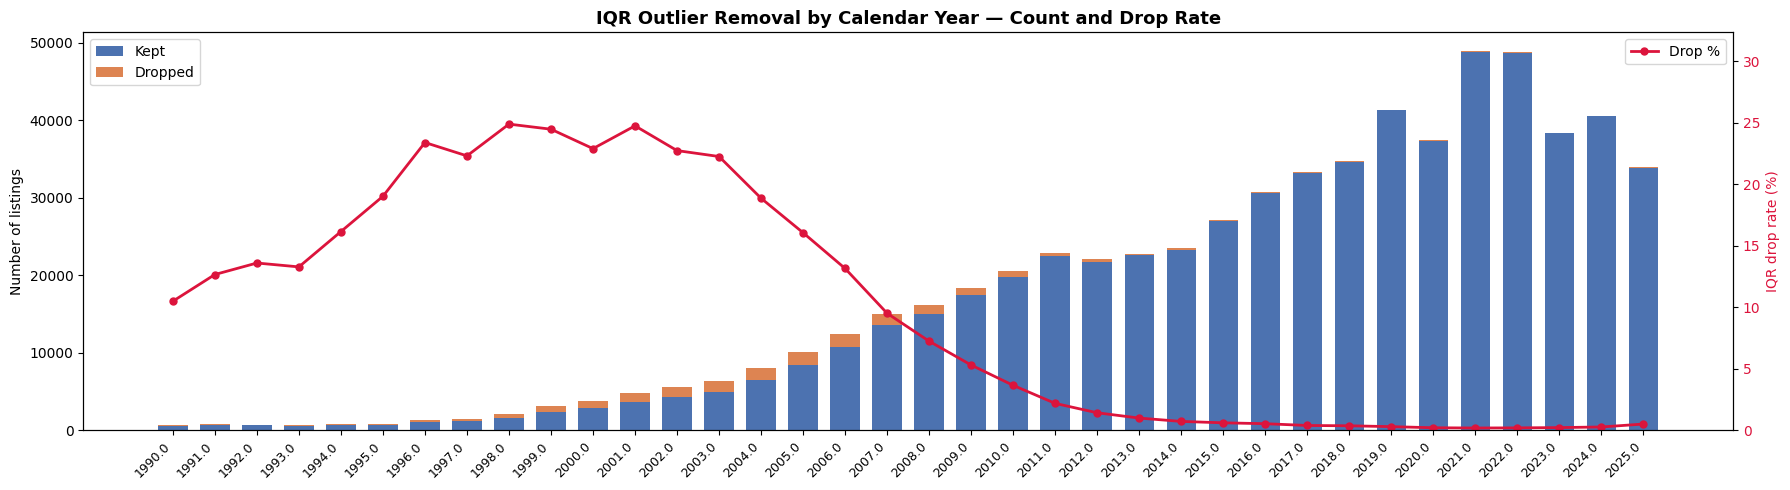

In [6]:
# ── Chart 1: Stacked bar per year + drop% line ───────────────────────────────
fig, ax1 = plt.subplots(figsize=(18, 5))

kept    = year_summary["n_total"] - year_summary["n_dropped"]
dropped = year_summary["n_dropped"]
years   = year_summary["year"]
x       = range(len(years))

ax1.bar(x, kept,    label="Kept",    color="#4C72B0", width=0.7)
ax1.bar(x, dropped, label="Dropped", color="#DD8452", width=0.7, bottom=kept)
ax1.set_xticks(list(x))
ax1.set_xticklabels(years, rotation=45, ha="right", fontsize=9)
ax1.set_ylabel("Number of listings")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(list(x), year_summary["drop_pct"], color="crimson", marker="o",
         linewidth=2, markersize=5, label="Drop %")
ax2.set_ylabel("IQR drop rate (%)", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.set_ylim(0, max(year_summary["drop_pct"]) * 1.3)
ax2.legend(loc="upper right")

ax1.set_title("IQR Outlier Removal by Calendar Year — Count and Drop Rate", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

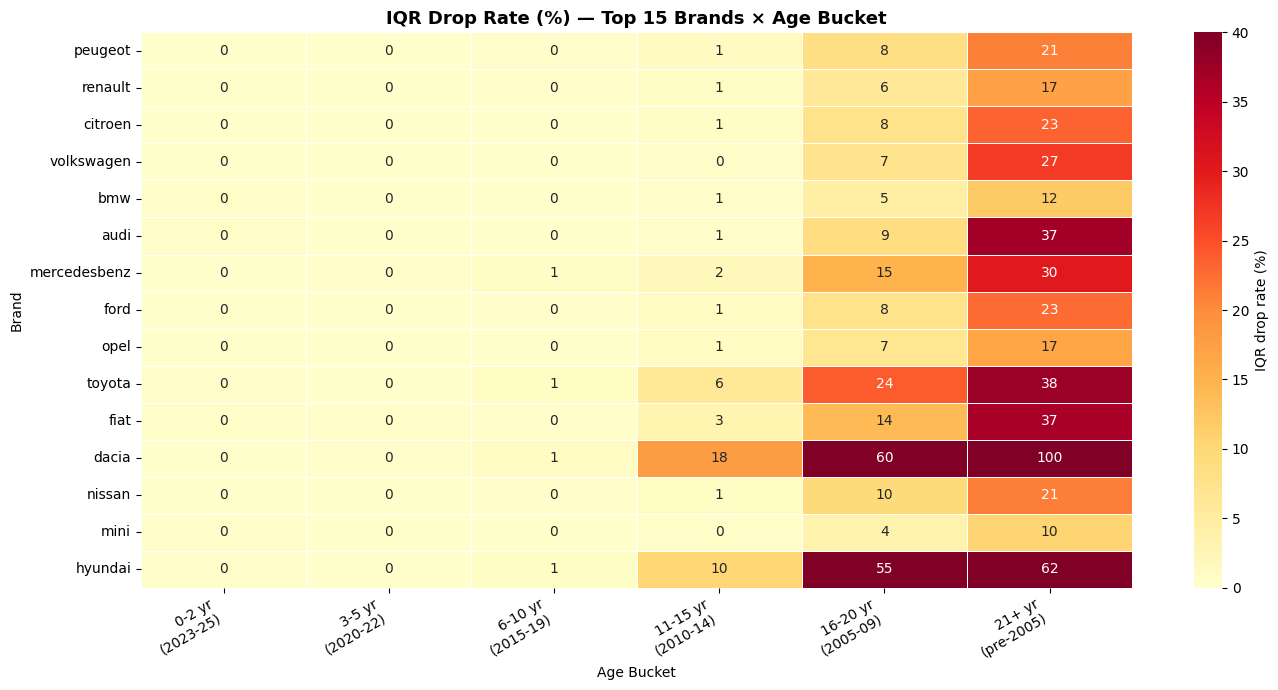

In [7]:
# ── Chart 2: Brand × age-bucket IQR drop rate heatmap ────────────────────────
# Build pivot: brand (rows) × year_bucket (cols), values = drop_pct
top_brands = (
    df_flagged
    .group_by("brand")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
    .head(15)["brand"]
    .to_list()
)

heatmap_data = (
    df_flagged
    .filter(pl.col("brand").is_in(top_brands))
    .group_by(["brand", "year_bucket"])
    .agg([
        pl.len().alias("n_total"),
        pl.col("is_iqr_outlier").sum().alias("n_dropped"),
    ])
    .with_columns(
        (100 * pl.col("n_dropped") / pl.col("n_total")).alias("drop_pct")
    )
    .to_pandas()
    .pivot(index="brand", columns="year_bucket", values="drop_pct")
    .reindex(columns=AGE_BUCKET_LABELS)
    .reindex(top_brands)
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd",
    linewidths=0.4, ax=ax, vmin=0, vmax=40,
    cbar_kws={"label": "IQR drop rate (%)"},
)
ax.set_title("IQR Drop Rate (%) — Top 15 Brands × Age Bucket", fontsize=13, fontweight="bold")
ax.set_xlabel("Age Bucket")
ax.set_ylabel("Brand")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

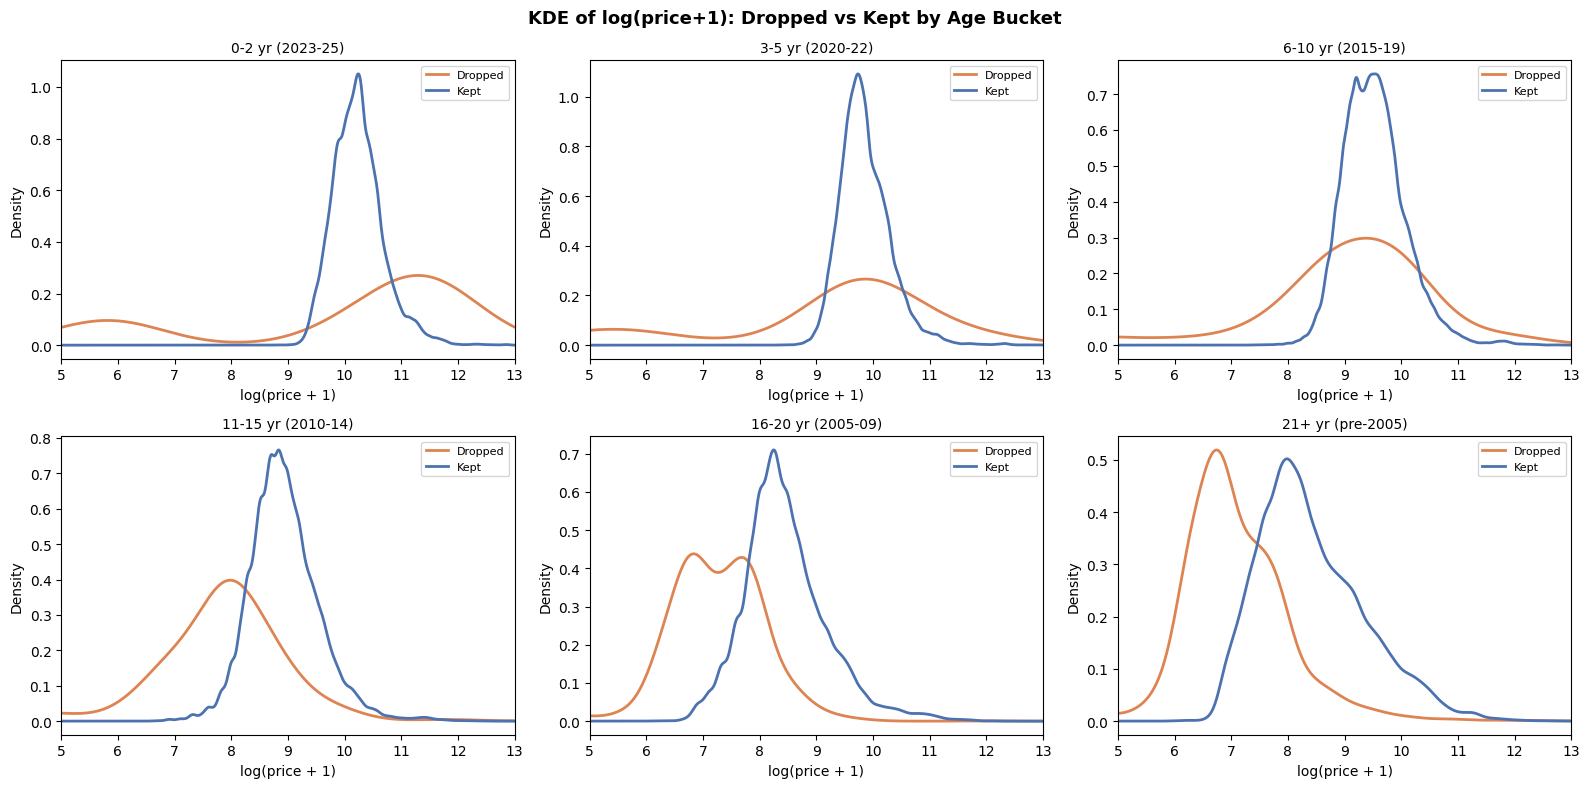

In [8]:
# ── Chart 3: KDE of log1p price — dropped vs kept, faceted by age bucket ─────
df_plot = df_flagged.select(["log_price_iqr", "is_iqr_outlier", "year_bucket"]).to_pandas()
df_plot["status"] = df_plot["is_iqr_outlier"].map({True: "Dropped", False: "Kept"})

n_buckets = len(AGE_BUCKET_LABELS)
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=False)
axes = axes.flatten()

for i, bucket in enumerate(AGE_BUCKET_LABELS):
    subset = df_plot[df_plot["year_bucket"] == bucket]
    if len(subset) < 5:
        axes[i].set_visible(False)
        continue
    for label, grp in subset.groupby("status"):
        if len(grp) > 5:
            grp["log_price_iqr"].plot.kde(ax=axes[i], label=label,
                                           linewidth=2,
                                           color="#DD8452" if label == "Dropped" else "#4C72B0")
    axes[i].set_title(bucket.replace("\n", " "), fontsize=10)
    axes[i].set_xlabel("log(price + 1)")
    axes[i].legend(fontsize=8)
    axes[i].set_xlim(5, 13)

fig.suptitle("KDE of log(price+1): Dropped vs Kept by Age Bucket", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

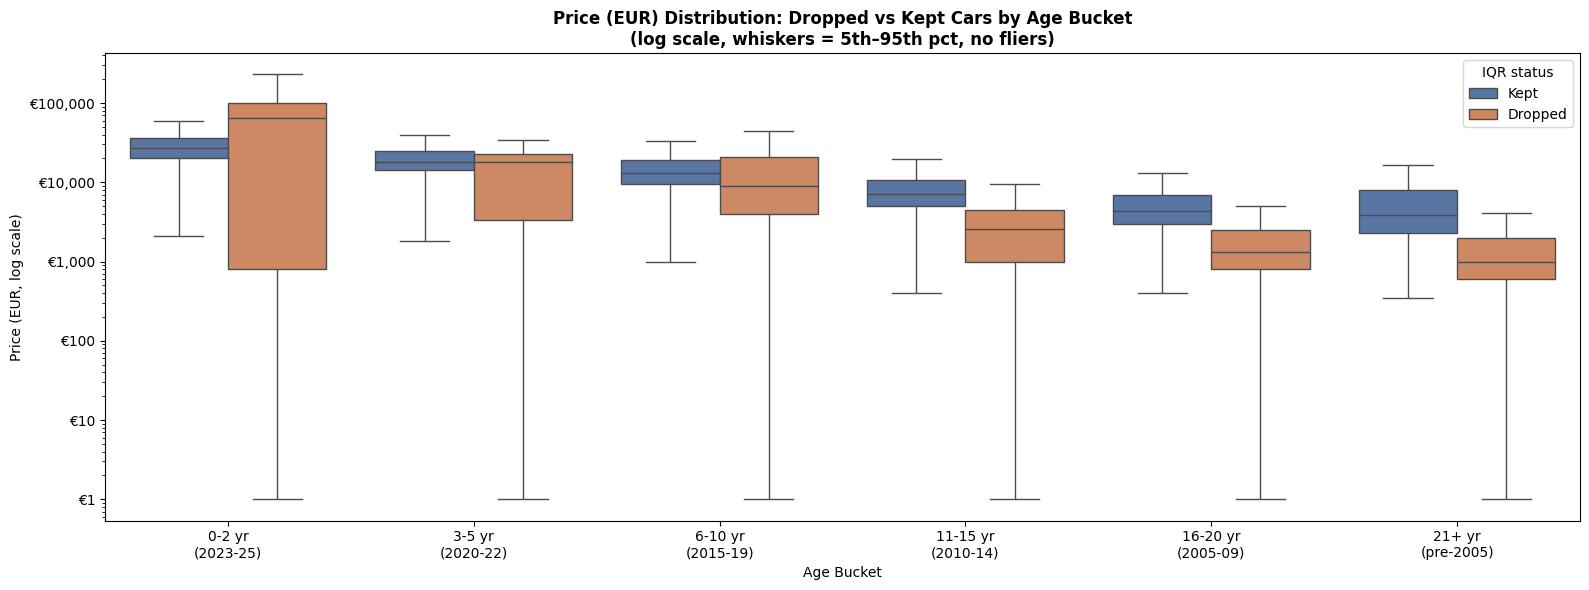

In [9]:
# ── Chart 4: Boxplot — price EUR dropped vs kept per age bucket ───────────────
df_box = df_flagged.select(["price", "is_iqr_outlier", "year_bucket"]).to_pandas()
df_box["status"] = df_box["is_iqr_outlier"].map({True: "Dropped", False: "Kept"})
df_box["_order"] = df_box["year_bucket"].map(
    {lab: i for i, (_, _, lab) in enumerate(AGE_BUCKETS)}
)
df_box = df_box.sort_values("_order")

fig, ax = plt.subplots(figsize=(16, 6))
palette = {"Kept": "#4C72B0", "Dropped": "#DD8452"}
sns.boxplot(
    data=df_box,
    x="year_bucket", y="price", hue="status",
    order=AGE_BUCKET_LABELS,
    palette=palette,
    showfliers=False,
    ax=ax,
)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:,.0f}"))
ax.set_title("Price (EUR) Distribution: Dropped vs Kept Cars by Age Bucket\n(log scale, whiskers = 5th–95th pct, no fliers)", fontsize=12, fontweight="bold")
ax.set_xlabel("Age Bucket")
ax.set_ylabel("Price (EUR, log scale)")
ax.legend(title="IQR status")
plt.tight_layout()
plt.show()

---

## Part B — Model Error by Year / Age Bracket

### B1. Reconstruct the Exact Test Set from Notebook 09

Must reproduce the same 80/20 split with `TRAIN_TEST_SEED = 42` and add `log_price` using plain `log()` (not log1p) to match nb09 Cell 3.

In [10]:
# Run full clean pipeline (includes IQR), then add log_price with plain log()
# to match nb09 Cell 3 exactly.
df = data_processing.clean_car_data(df_raw, verbose=False)
df = df.with_columns(pl.col("price").log().alias("log_price"))

# Reproduce the same train/test split as nb09
train_indices, test_indices = train_test_split(
    range(len(df)), test_size=0.2, random_state=TRAIN_TEST_SEED
)
df_train = df[train_indices]
df_test  = df[test_indices]

# Metadata arrays for grouping
years_test    = df_test["year"].to_numpy()
car_age_test  = CURRENT_YEAR - years_test
y_test_eur    = df_test["price"].to_numpy()
brands_test   = df_test["brand"].to_numpy()

print(f"Clean after IQR : {len(df):,} rows")
print(f"Train: {len(df_train):,}  |  Test: {len(df_test):,}")
print(f"Test year range : {years_test.min()} – {years_test.max()}")
print(f"Test price range: €{y_test_eur.min():,.0f} – €{y_test_eur.max():,.0f}")

Clean after IQR : 620,918 rows
Train: 496,734  |  Test: 124,184
Test year range : 1990.0 – 2025.0
Test price range: €400 – €629,990


### B2. Feature Engineering for `lean_full` Spec

Fits `CarPriceFeatureEngineer` on the training set (no brand/model OHE, no km, no HP, no energie), then transforms both sets. This is the identical configuration used in nb09 for `lean_full`.

In [11]:
# Identical to nb09 _NO_OHE config for lean_full
fe_full = CarPriceFeatureEngineer(
    current_year=CURRENT_YEAR,
    brand_onehot=False,
    model_onehot=False,
    add_horsepower_features=False,
    add_energie_ohe=False,
)
fe_full.fit(df_train.drop(["price", "log_price"]), df_train["price"])
df_test_fe = fe_full.transform(df_test)

print(f"Feature-engineered test set: {df_test_fe.shape}")
print(f"Sample columns: {df_test_fe.columns[:10]}")

Feature-engineered test set: (124184, 58)
Sample columns: ['price', 'year', 'km', 'energie', 'horsepower', 'log_price', 'car_age', 'decade', 'is_almost_new', 'age_category']


### B3. Load Saved Models and Generate Predictions

Loads q15 / q50 / q85 pkl files from `output/mlflow_artifacts/`. Feature list is read from the model's `feature_name_` attribute (identical to how nb09 does it).

In [12]:
SPEC_TO_ANALYZE = "lean_full"   # ← change this single variable to swap specs

models = {}
for q_label in ["q15", "q50", "q85"]:
    pkl_path = ARTIFACTS_DIR / f"{SPEC_TO_ANALYZE}_{q_label}_model.pkl"
    models[q_label] = joblib.load(pkl_path)
    print(f"Loaded {pkl_path.name}  ({len(models[q_label].feature_name_)} features)")

# Build X_test using feature names from the q50 model
feat_cols = models["q50"].feature_name_
available  = [c for c in feat_cols if c in df_test_fe.columns]
missing    = [c for c in feat_cols if c not in df_test_fe.columns]
if missing:
    print(f"WARNING: {len(missing)} features missing from df_test_fe: {missing[:5]}")

X_test = df_test_fe.select(available).to_pandas().fillna(0)

# Predict in log-price space, then exponentiate to EUR
y_pred_log = {q: models[q].predict(X_test) for q in models}
y_pred_eur = {q: np.exp(y_pred_log[q]) for q in models}

print(f"\nX_test shape : {X_test.shape}")
print(f"q50 MAE      : €{mean_absolute_error(y_test_eur, y_pred_eur['q50']):,.0f}")

Loaded lean_full_q15_model.pkl  (31 features)
Loaded lean_full_q50_model.pkl  (31 features)
Loaded lean_full_q85_model.pkl  (31 features)

X_test shape : (124184, 31)
q50 MAE      : €2,562


### B4. Metric Helper Functions

Primary metric: `pct_err_over_year_median = mean(|actual − pred|) / median(actual prices in year) × 100`  
Signed bias: `median((pred − actual) / actual × 100)`  
Coverage: fraction of actuals inside the [q15, q85] interval.

In [13]:
def compute_year_metrics(
    y_true_eur: np.ndarray,
    y_pred_q50_eur: np.ndarray,
    y_pred_q15_eur: np.ndarray,
    y_pred_q85_eur: np.ndarray,
    group_vals: np.ndarray,
    group_label: str = "year",
) -> pd.DataFrame:
    """
    Compute per-group error metrics normalised to that group's median price.

    Returns a DataFrame with columns:
      {group_label}, n, median_price_eur,
      pct_err_over_median  – primary metric
      mae_eur              – raw MAE (informational only)
      mape_pct             – MAPE %
      median_signed_pct    – median signed % error (bias indicator)
      coverage_70          – fraction inside [q15, q85] interval
    """
    rows = []
    for gval in sorted(np.unique(group_vals)):
        mask = group_vals == gval
        if mask.sum() < 3:
            continue
        act  = y_true_eur[mask]
        pred = y_pred_q50_eur[mask]
        lo   = y_pred_q15_eur[mask]
        hi   = y_pred_q85_eur[mask]

        med_price = np.median(act)
        mae_val   = mean_absolute_error(act, pred)
        rows.append({
            group_label:             gval,
            "n":                     int(mask.sum()),
            "median_price_eur":      round(med_price, 0),
            "pct_err_over_median":   round(100 * mae_val / med_price, 2),
            "mae_eur":               round(mae_val, 0),
            "mape_pct":              round(100 * np.mean(np.abs((act - pred) / np.clip(act, 1, None))), 2),
            "median_signed_pct":     round(float(np.median((pred - act) / np.clip(act, 1, None) * 100)), 2),
            "coverage_70":           round(float(np.mean((lo <= act) & (act <= hi))), 4),
        })
    return pd.DataFrame(rows)


def compute_age_bucket_metrics(
    y_true_eur: np.ndarray,
    y_pred_q50_eur: np.ndarray,
    y_pred_q15_eur: np.ndarray,
    y_pred_q85_eur: np.ndarray,
    car_ages: np.ndarray,
) -> pd.DataFrame:
    """Same as compute_year_metrics but groups by AGE_BUCKETS."""
    bucket_labels = np.array([age_to_bucket_label(a) for a in car_ages])
    df = compute_year_metrics(
        y_true_eur, y_pred_q50_eur, y_pred_q15_eur, y_pred_q85_eur,
        bucket_labels, group_label="year_bucket",
    )
    df["_order"] = df["year_bucket"].map(
        {lab: i for i, (_, _, lab) in enumerate(AGE_BUCKETS)}
    )
    return df.sort_values("_order").drop(columns="_order").reset_index(drop=True)


# ── Compute metrics ───────────────────────────────────────────────────────────
year_metrics   = compute_year_metrics(
    y_test_eur, y_pred_eur["q50"], y_pred_eur["q15"], y_pred_eur["q85"],
    years_test, "year",
)
bucket_metrics = compute_age_bucket_metrics(
    y_test_eur, y_pred_eur["q50"], y_pred_eur["q15"], y_pred_eur["q85"],
    car_age_test,
)

print("=== By year (first 10 rows) ===")
print(year_metrics.head(10).to_string(index=False))
print("\n=== By age bucket ===")
print(bucket_metrics.to_string(index=False))

=== By year (first 10 rows) ===
  year   n  median_price_eur  pct_err_over_median  mae_eur  mape_pct  median_signed_pct  coverage_70
1990.0 117           12000.0                38.88   4666.0     50.46              -2.07       0.6496
1991.0 122            8500.0                65.60   5576.0     58.03              -6.52       0.6066
1992.0 128            8490.0                60.46   5133.0     46.96             -11.04       0.6562
1993.0 109            7600.0                80.92   6150.0     53.97             -11.54       0.6514
1994.0 112            4100.0               124.04   5086.0     61.77              -3.94       0.6518
1995.0 111            4000.0               121.32   4853.0     52.40              -2.67       0.6306
1996.0 187            4700.0                80.39   3778.0     41.35               0.92       0.6898
1997.0 239            5500.0                80.59   4432.0     42.12              -3.37       0.6192
1998.0 337            4000.0                63.63   2545.0 

### B5. Performance Visualisations

**Chart 5** — `pct_err_over_median` by calendar year (line + confidence band)  
**Chart 6** — Signed bias (median % over/under) by year  
**Chart 7** — Interval coverage (q15–q85) by year  
**Chart 8** — Age-bucket bar chart: `pct_err_over_median` + count overlay  
**Chart 9** — Signed bias by age bucket (horizontal bar)

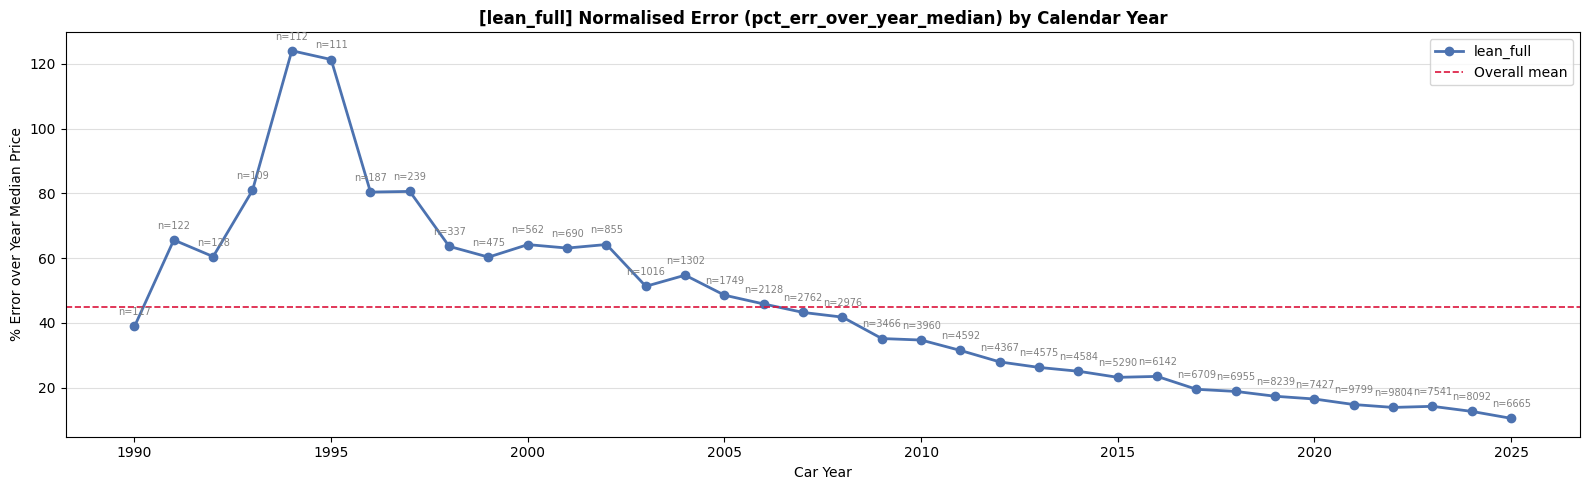

In [14]:
# ── Chart 5: pct_err_over_median by year ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(year_metrics["year"], year_metrics["pct_err_over_median"],
        marker="o", linewidth=2.0, color="#4C72B0", markersize=6, label=SPEC_TO_ANALYZE)

# Annotate n for context
for _, row in year_metrics.iterrows():
    ax.annotate(
        f"n={int(row['n'])}",
        (row["year"], row["pct_err_over_median"]),
        textcoords="offset points", xytext=(0, 8),
        fontsize=7, ha="center", color="grey",
    )

ax.axhline(year_metrics["pct_err_over_median"].mean(), color="crimson",
           linestyle="--", linewidth=1.2, label="Overall mean")
ax.set_xlabel("Car Year")
ax.set_ylabel("% Error over Year Median Price")
ax.set_title(f"[{SPEC_TO_ANALYZE}] Normalised Error (pct_err_over_year_median) by Calendar Year",
             fontsize=12, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

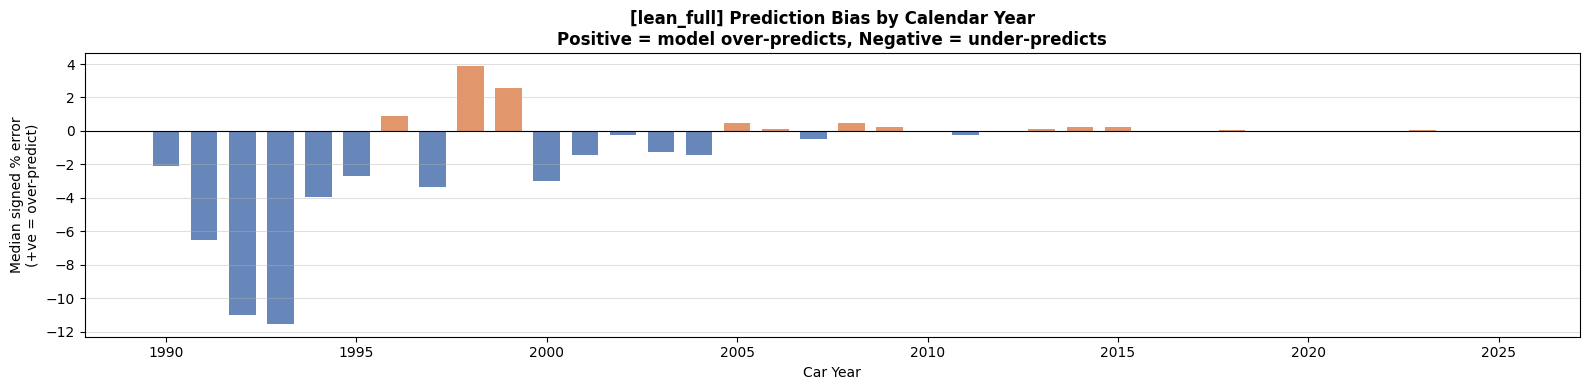

In [15]:
# ── Chart 6: Signed bias (median % over/under) by year ───────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

colors = ["#DD8452" if v > 0 else "#4C72B0" for v in year_metrics["median_signed_pct"]]
ax.bar(year_metrics["year"], year_metrics["median_signed_pct"], color=colors, width=0.7, alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Car Year")
ax.set_ylabel("Median signed % error\n(+ve = over-predict)")
ax.set_title(f"[{SPEC_TO_ANALYZE}] Prediction Bias by Calendar Year\n"
             "Positive = model over-predicts, Negative = under-predicts",
             fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

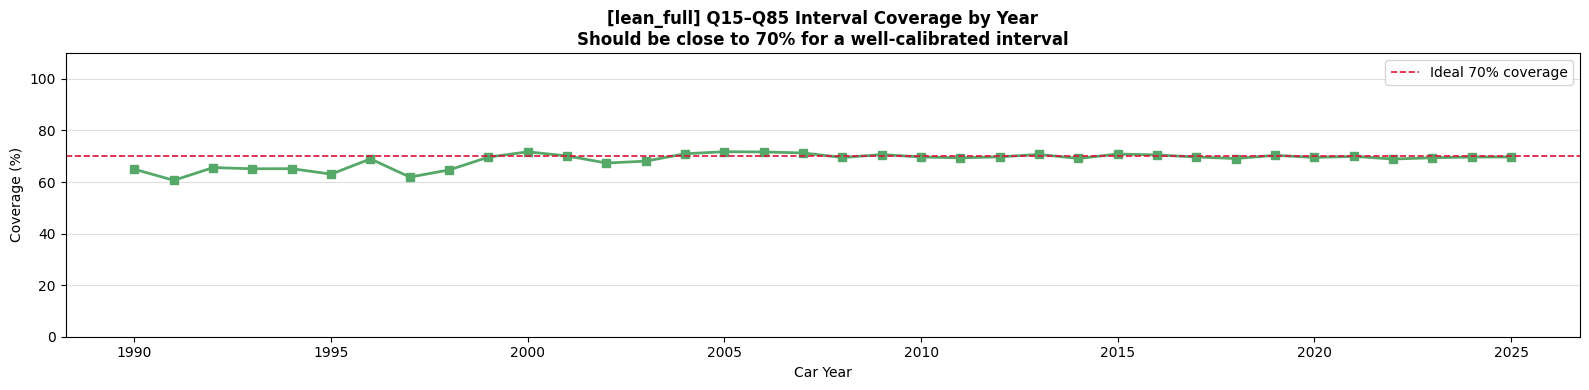

In [16]:
# ── Chart 7: Interval coverage (q15–q85) by year ─────────────────────────────
# Target coverage for a 70% interval is ~0.70
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(year_metrics["year"], year_metrics["coverage_70"] * 100,
        marker="s", linewidth=2.0, color="#55A868", markersize=6)
ax.axhline(70, color="crimson", linestyle="--", linewidth=1.2, label="Ideal 70% coverage")
ax.set_xlabel("Car Year")
ax.set_ylabel("Coverage (%)")
ax.set_ylim(0, 110)
ax.set_title(f"[{SPEC_TO_ANALYZE}] Q15–Q85 Interval Coverage by Year\n"
             "Should be close to 70% for a well-calibrated interval",
             fontsize=12, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

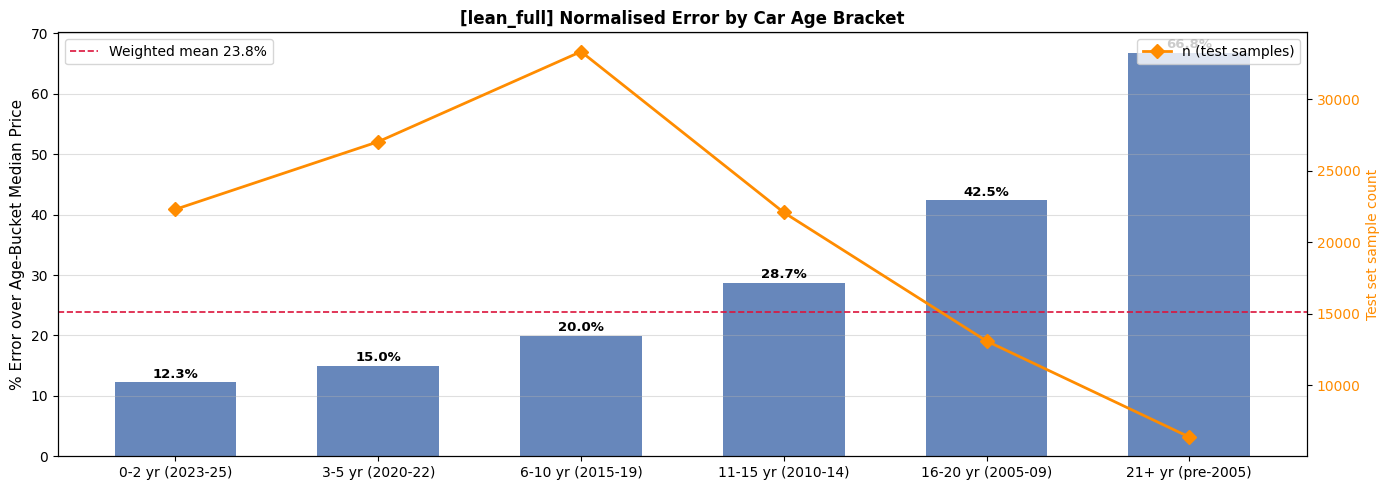

In [17]:
# ── Chart 8: Age-bucket bar — pct_err_over_median + sample count overlay ─────
fig, ax1 = plt.subplots(figsize=(14, 5))

xlabels = [b.replace("\n", " ") for b in bucket_metrics["year_bucket"]]
x       = range(len(xlabels))
bars    = ax1.bar(x, bucket_metrics["pct_err_over_median"], color="#4C72B0", width=0.6, alpha=0.85)
ax1.set_xticks(list(x))
ax1.set_xticklabels(xlabels, fontsize=10)
ax1.set_ylabel("% Error over Age-Bucket Median Price", fontsize=11)
ax1.set_title(f"[{SPEC_TO_ANALYZE}] Normalised Error by Car Age Bracket",
              fontsize=12, fontweight="bold")

# Annotate bar values
for bar, val in zip(bars, bucket_metrics["pct_err_over_median"]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=9.5, fontweight="bold")

ax2 = ax1.twinx()
ax2.plot(list(x), bucket_metrics["n"], color="darkorange",
         marker="D", linewidth=2, markersize=7, label="n (test samples)")
ax2.set_ylabel("Test set sample count", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")
ax2.legend(loc="upper right")

# Overall mean reference
overall_mean = (bucket_metrics["pct_err_over_median"] * bucket_metrics["n"]).sum() / bucket_metrics["n"].sum()
ax1.axhline(overall_mean, color="crimson", linestyle="--", linewidth=1.2,
            label=f"Weighted mean {overall_mean:.1f}%")
ax1.legend(loc="upper left")
ax1.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

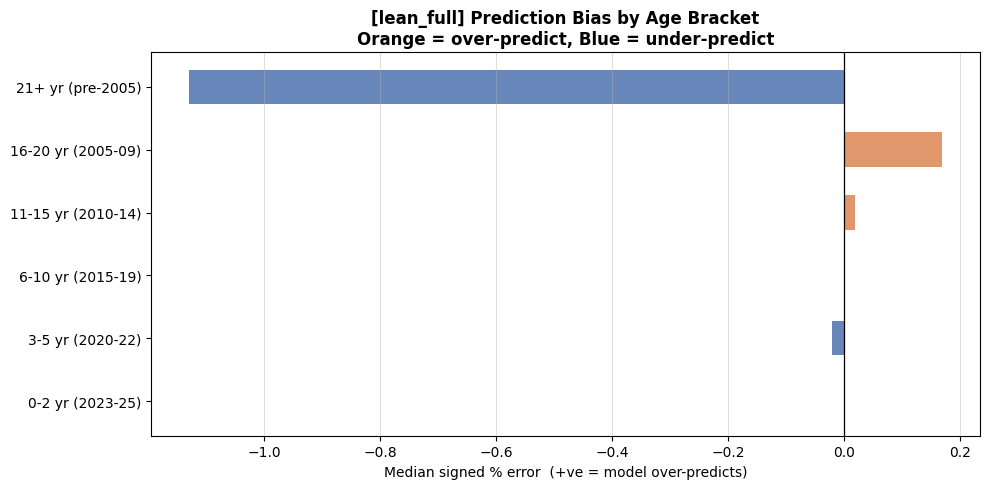

In [18]:
# ── Chart 9: Signed bias by age bucket (horizontal diverging bar) ─────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#DD8452" if v > 0 else "#4C72B0" for v in bucket_metrics["median_signed_pct"]]
xlabels_h = [b.replace("\n", " ") for b in bucket_metrics["year_bucket"]]
y_pos = range(len(xlabels_h))

ax.barh(list(y_pos), bucket_metrics["median_signed_pct"], color=colors, alpha=0.85, height=0.55)
ax.axvline(0, color="black", linewidth=0.9)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(xlabels_h, fontsize=10)
ax.set_xlabel("Median signed % error  (+ve = model over-predicts)", fontsize=10)
ax.set_title(f"[{SPEC_TO_ANALYZE}] Prediction Bias by Age Bracket\n"
             "Orange = over-predict, Blue = under-predict",
             fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.show()

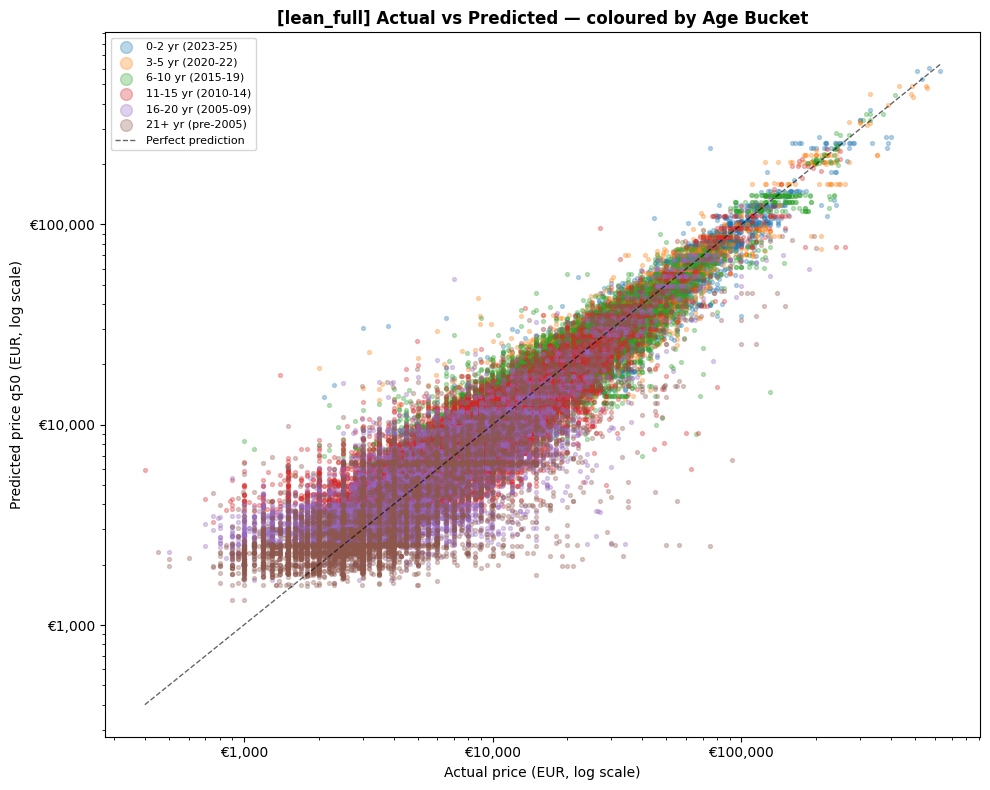

In [19]:
# ── Chart 10: Scatter — actual vs predicted, coloured by age bucket ───────────
bucket_labels_test = np.array([age_to_bucket_label(a) for a in car_age_test])
palette_buckets    = sns.color_palette("tab10", n_colors=len(AGE_BUCKET_LABELS))
color_map          = {lab: col for lab, col in zip(AGE_BUCKET_LABELS, palette_buckets)}

fig, ax = plt.subplots(figsize=(10, 8))

for bucket in AGE_BUCKET_LABELS:
    mask = bucket_labels_test == bucket
    if mask.sum() == 0:
        continue
    ax.scatter(
        y_test_eur[mask], y_pred_eur["q50"][mask],
        alpha=0.3, s=8,
        color=color_map[bucket],
        label=bucket.replace("\n", " "),
    )

lims = [min(y_test_eur.min(), y_pred_eur["q50"].min()),
        max(y_test_eur.max(), y_pred_eur["q50"].max())]
ax.plot(lims, lims, 'k--', linewidth=1.0, alpha=0.6, label="Perfect prediction")
ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:,.0f}"))
ax.set_xlabel("Actual price (EUR, log scale)")
ax.set_ylabel("Predicted price q50 (EUR, log scale)")
ax.set_title(f"[{SPEC_TO_ANALYZE}] Actual vs Predicted — coloured by Age Bucket",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=8, markerscale=3, loc="upper left")
plt.tight_layout()
plt.show()

---

## Part C — Alternative Cleaning Strategy: Prototype

Testing a three-stage pipeline designed to eliminate age-cohort bias in IQR outlier removal:

1. **25-year age cap** — remove cars older than 25 years (pre-2000); data is too sparse and pricing too noisy for the model.
2. **Global 1% price cut** — remove absolute price extremes (likely data-entry errors) *before* any group-based statistics are computed. Operates on the full dataset, independent of brand or year.
3. **Brand + year IQR** — compute IQR per `(brand, year)` bucket instead of per `brand` only:
   - Groups with **≥ 50 cars** → `(brand, year)` IQR directly at 1.5×.
   - Groups with **< 50 cars** → expand window to `year ± 1` (3-year pool) and compute IQR on that pool.
   - Groups still below **10 cars** after expansion → no IQR removal (too sparse to compute meaningful bounds).


In [ ]:
# ── C1: Apply 25-year age cutoff ─────────────────────────────────────────────
MAX_AGE_NEW  = 25
MIN_YEAR_NEW = int(CURRENT_YEAR - MAX_AGE_NEW)   # 2000

removed_old = df_pre_iqr.filter(pl.col("year") < MIN_YEAR_NEW)
df_c_age    = df_pre_iqr.filter(pl.col("year") >= MIN_YEAR_NEW)

n_removed_age = len(df_pre_iqr) - len(df_c_age)
print(f"Min year cutoff  : {MIN_YEAR_NEW}  (max age {MAX_AGE_NEW} yrs, relative to CURRENT_YEAR={CURRENT_YEAR})")
print(f"Rows removed     : {n_removed_age:,}  ({100*n_removed_age/len(df_pre_iqr):.1f}%)")
print(f"Rows remaining   : {len(df_c_age):,}")

print("\nRemoved rows by year:")
print(
    removed_old.group_by("year").agg(pl.len().alias("n")).sort("year").to_pandas().to_string(index=False)
)


In [ ]:
# ── C2: Price bounds exploration ──────────────────────────────────────────────
prices_s = df_c_age["price"].drop_nulls()
total    = len(prices_s)

# ── Bottom: fixed €500 floor ──────────────────────────────────────────────────
P_LOW   = 500.0
n_below = int((prices_s < P_LOW).sum())
print(f"Cars below €{P_LOW:,.0f}  :  {n_below:,}  ({100*n_below/total:.3f}% of dataset)")
print()

# ── Top: bracket-by-bracket exploration (€250k → €600k in €50k steps) ────────
cuts = [250_000, 300_000, 350_000, 400_000, 450_000, 500_000, 550_000, 600_000]
print("Upper bound exploration — cars removed at each cut-off level:")
print(f"  {'Cut at':>10}   {'In this bracket':>16}   {'Cumul. removed':>15}   {'Cumul. %':>9}")
print("  " + "-" * 57)
for i, cut in enumerate(cuts):
    n_cumul = int((prices_s > cut).sum())
    if i < len(cuts) - 1:
        n_bracket = int(((prices_s > cut) & (prices_s <= cuts[i + 1])).sum())
        bracket   = f"€{cut//1000:,}k – €{cuts[i+1]//1000:,}k"
    else:
        n_bracket = n_cumul
        bracket   = f"> €{cut//1000:,}k"
    print(f"  {bracket:>10}   {n_bracket:>16,}   {n_cumul:>15,}   {100*n_cumul/total:>8.3f}%")

print()
print("→ Applying only the lower bound for now (upper TBD after reviewing the table above).")
print(f"  P_LOW = €{P_LOW:,.0f}")

# Apply lower bound only + drop null km/year rows + add derived columns
df_c_global = (
    df_c_age
    .filter(
        (pl.col("price") >= P_LOW)
        & pl.col("km").is_not_null()
        & pl.col("year").is_not_null()
        & (pl.col("km") >= 0)
    )
    .with_columns([
        (pl.col("price") + 1).log().alias("log_price_iqr"),
        pl.col("year").cast(pl.Int32).alias("year_int"),
    ])
)

n_removed = len(df_c_age) - len(df_c_global)
print(f"\nAfter lower bound + null drop: {len(df_c_global):,} rows  (removed {n_removed:,})")


In [ ]:
# ── C3: Brand+year group size analysis ────────────────────────────────────────
brand_year_sizes = (
    df_c_global.group_by(["brand", "year_int"]).agg(pl.len().alias("n_group"))
)
group_sizes_pd = brand_year_sizes.to_pandas()

total_groups  = len(group_sizes_pd)
n_small       = int((group_sizes_pd["n_group"] < 50).sum())
n_large       = total_groups - n_small
cars_in_small = int(group_sizes_pd.loc[group_sizes_pd["n_group"] < 50, "n_group"].sum())
cars_in_large = int(group_sizes_pd.loc[group_sizes_pd["n_group"] >= 50, "n_group"].sum())

print(f"(brand, year) group summary:")
print(f"  Total groups       : {total_groups:,}")
print(f"  Large (≥50 cars)  : {n_large:,}  ({100*n_large/total_groups:.1f}%)  → brand+year IQR")
print(f"  Small (<50 cars)  : {n_small:,}  ({100*n_small/total_groups:.1f}%)  → brand+(year±1) IQR")
print(f"  Cars in large grps : {cars_in_large:,}")
print(f"  Cars in small grps : {cars_in_small:,}")

# Distribution of small groups by year
sizes_by_year = (
    group_sizes_pd
    .groupby("year_int", as_index=False)
    .agg(
        n_groups=("n_group", "count"),
        n_small=("n_group", lambda x: (x < 50).sum()),
        median_size=("n_group", "median"),
    )
    .assign(pct_small=lambda d: 100 * d["n_small"] / d["n_groups"])
    .sort_values("year_int")
)
print("\nSmall groups (<50 cars) by year:")
print(sizes_by_year.to_string(index=False))

# Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

group_sizes_pd["n_group"].clip(upper=300).hist(bins=50, ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].axvline(50, color="crimson", linestyle="--", linewidth=1.5, label="50-car threshold")
axes[0].set_xlabel("Group size (capped at 300 for display)")
axes[0].set_ylabel("Number of (brand, year) groups")
axes[0].set_title("Distribution of brand+year group sizes")
axes[0].legend()

axes[1].bar(sizes_by_year["year_int"],
            sizes_by_year["n_small"],
            color="#DD8452", label="Small (<50)")
axes[1].bar(sizes_by_year["year_int"],
            sizes_by_year["n_groups"] - sizes_by_year["n_small"],
            bottom=sizes_by_year["n_small"],
            color="#4C72B0", label="Large (≥50)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of (brand, year) groups")
axes[1].set_title("Large vs small groups by year")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Prepare pandas df for bound computation in next cell
df_pd_c = (
    df_c_global
    .select(["brand", "year_int", "log_price_iqr", "km"])
    .to_pandas()
    .merge(group_sizes_pd, on=["brand", "year_int"])
)
print(f"\ndf_pd_c ready: {len(df_pd_c):,} rows  columns: {list(df_pd_c.columns)}")


In [ ]:
# ── C4: Compute brand+year IQR bounds (large groups vectorised, small iterative)
IQR_MULT = 1.5
MIN_POOL  = 10   # min pool size after ±1 expansion to compute a meaningful IQR

# ── Large groups (≥50): vectorised per (brand, year) ─────────────────────────
large_df = df_pd_c[df_pd_c["n_group"] >= 50]

def _vec_bounds(grp_df, col, mult=IQR_MULT):
    q = grp_df.groupby(["brand", "year_int"])[col].quantile([0.25, 0.75]).unstack()
    q.columns = ["q1", "q3"]
    q["iqr"] = q["q3"] - q["q1"]
    q["lo"]  = q["q1"] - mult * q["iqr"]
    q["hi"]  = q["q3"] + mult * q["iqr"]
    return q[["lo", "hi"]].reset_index()

lp_large = _vec_bounds(large_df, "log_price_iqr").rename(columns={"lo": "lo_lp", "hi": "hi_lp"})
km_large = _vec_bounds(large_df, "km").rename(columns={"lo": "lo_km", "hi": "hi_km"})
large_bounds = lp_large.merge(km_large, on=["brand", "year_int"])
large_bounds["source"] = "brand_year"

print(f"Large groups computed: {len(large_bounds):,}")

# ── Small groups (<50): year±1 window IQR, iterative ─────────────────────────
def _iqr_lo_hi(series, mult=IQR_MULT):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    return q1 - mult * (q3 - q1), q3 + mult * (q3 - q1)

small_keys = group_sizes_pd[group_sizes_pd["n_group"] < 50][["brand", "year_int"]].values
small_rows = []

for brand, year in small_keys:
    year = int(year)
    pool = df_pd_c[
        (df_pd_c["brand"] == brand)
        & (df_pd_c["year_int"] >= year - 1)
        & (df_pd_c["year_int"] <= year + 1)
    ]
    if len(pool) >= MIN_POOL:
        lo_lp, hi_lp = _iqr_lo_hi(pool["log_price_iqr"])
        lo_km, hi_km = _iqr_lo_hi(pool["km"])
        src = "brand_year_pm1"
    else:
        lo_lp, hi_lp, lo_km, hi_km = -np.inf, np.inf, -np.inf, np.inf
        src = "no_bound"
    small_rows.append({
        "brand": brand, "year_int": year,
        "lo_lp": lo_lp, "hi_lp": hi_lp,
        "lo_km": lo_km, "hi_km": hi_km,
        "source": src,
    })

small_bounds = pd.DataFrame(small_rows)
all_bounds   = pd.concat([large_bounds, small_bounds], ignore_index=True)

print(f"Small groups computed : {len(small_bounds):,}")
print(f"\nBound source breakdown:\n{all_bounds['source'].value_counts().to_string()}")

# ── No-bound groups: inspect which (brand, year) combinations are too sparse ──
no_bound = all_bounds[all_bounds["source"] == "no_bound"][["brand", "year_int"]].copy()
n_no_bound = len(no_bound)
print(f"\nGroups with no bound (pool < {MIN_POOL} even after ±1 expansion): {n_no_bound}")

if n_no_bound > 0:
    # How many cars sit in these unbound groups?
    unbound_cars = df_pd_c.merge(no_bound, on=["brand", "year_int"])
    print(f"Cars in unbound groups: {len(unbound_cars):,}  "
          f"(kept as-is — no outlier removal applied)\n")

    # Full list sorted by year then brand
    no_bound_display = (
        no_bound
        .merge(
            df_pd_c.groupby(["brand", "year_int"], as_index=False).size().rename(columns={"size": "n_cars"}),
            on=["brand", "year_int"],
        )
        .sort_values(["year_int", "brand"])
        .reset_index(drop=True)
    )
    print("Full list of unbound (brand, year) groups:")
    print(no_bound_display.to_string(index=False))


In [ ]:
# ── C5: Apply new bounds, flag outliers, compute year summary ─────────────────
df_flagged_new = df_pd_c.merge(all_bounds, on=["brand", "year_int"], how="left")

df_flagged_new["is_new_outlier"] = (
    (df_flagged_new["log_price_iqr"] < df_flagged_new["lo_lp"])
    | (df_flagged_new["log_price_iqr"] > df_flagged_new["hi_lp"])
    | (df_flagged_new["km"]           < df_flagged_new["lo_km"])
    | (df_flagged_new["km"]           > df_flagged_new["hi_km"])
)

n_total_new   = len(df_flagged_new)
n_dropped_new = int(df_flagged_new["is_new_outlier"].sum())
print(f"New approach — total: {n_total_new:,}  "
      f"dropped: {n_dropped_new:,}  ({100*n_dropped_new/n_total_new:.2f}%)")
print(f"Kept: {n_total_new - n_dropped_new:,}")

# Year-level summary (used for comparison chart in next cell)
new_year_summary = (
    df_flagged_new
    .groupby("year_int", as_index=False)
    .agg(n_total=("is_new_outlier", "count"), n_dropped=("is_new_outlier", "sum"))
    .rename(columns={"year_int": "year"})
    .sort_values("year")
)
new_year_summary["drop_pct"] = 100 * new_year_summary["n_dropped"] / new_year_summary["n_total"]

print("\nNew approach drop rate by year:")
print(new_year_summary.to_string(index=False))


In [ ]:
# ── C6: Reproduced chart — new approach stacked bar + drop% comparison ────────
orig_restricted = (
    year_summary[year_summary["year"] >= MIN_YEAR_NEW]
    .copy()
    .assign(year=lambda d: d["year"].astype(int))
    .sort_values("year")
)

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(18, 10))

# ── Panel 1: stacked bar for NEW approach (same style as Part A Chart 1) ─────
kept_new    = new_year_summary["n_total"] - new_year_summary["n_dropped"]
dropped_new = new_year_summary["n_dropped"]
years_new   = new_year_summary["year"].astype(int)
x_new       = range(len(years_new))

ax_top.bar(list(x_new), kept_new,    label="Kept",    color="#4C72B0", width=0.7)
ax_top.bar(list(x_new), dropped_new, label="Dropped", color="#DD8452", width=0.7, bottom=kept_new)
ax_top.set_xticks(list(x_new))
ax_top.set_xticklabels(years_new, rotation=45, ha="right", fontsize=8)
ax_top.set_ylabel("Number of listings")
ax_top.legend(loc="upper left")
ax_top.set_title(
    f"NEW strategy — Count and drop rate by year  "
    f"(25-yr cap · global 1% · brand+year IQR · year±1 fallback for <{MIN_POOL} cars)",
    fontsize=11, fontweight="bold",
)
ax_top2 = ax_top.twinx()
ax_top2.plot(list(x_new), new_year_summary["drop_pct"],
             color="crimson", marker="o", linewidth=2, markersize=4, label="Drop % (new)")
ax_top2.set_ylabel("IQR drop rate (%)", color="crimson")
ax_top2.tick_params(axis="y", labelcolor="crimson")
ax_top2.set_ylim(0, max(new_year_summary["drop_pct"].max(), 1) * 1.4)
ax_top2.legend(loc="upper right")

# ── Panel 2: drop% overlay — original vs new ─────────────────────────────────
all_years  = sorted(set(orig_restricted["year"]) | set(new_year_summary["year"].astype(int)))
year_to_x  = {y: i for i, y in enumerate(all_years)}
orig_x     = [year_to_x[y] for y in orig_restricted["year"]]
new_x      = [year_to_x[y] for y in new_year_summary["year"].astype(int)]

ax_bot.plot(orig_x, orig_restricted["drop_pct"],
            color="#4C72B0", marker="o", linewidth=2, markersize=4,
            label=f"Original  (brand IQR, years ≥{MIN_YEAR_NEW})")
ax_bot.plot(new_x, new_year_summary["drop_pct"],
            color="crimson", marker="s", linewidth=2, markersize=4,
            label="New strategy")
ax_bot.set_xticks(range(len(all_years)))
ax_bot.set_xticklabels(all_years, rotation=45, ha="right", fontsize=8)
ax_bot.set_ylabel("IQR drop rate (%)")
ax_bot.set_title("Drop rate comparison: Original vs New strategy (per calendar year)",
                 fontsize=11, fontweight="bold")
ax_bot.legend()
ax_bot.grid(axis="y", alpha=0.4)

plt.suptitle("Alternative Cleaning Strategy — Impact on Outlier Removal",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
# ── C7: Drop rate by age bucket — before vs after ────────────────────────────
NEW_AGE_BUCKETS = [
    (0,  2,  "0-2 yr (2023-25)"),
    (3,  5,  "3-5 yr (2020-22)"),
    (6,  10, "6-10 yr (2015-19)"),
    (11, 15, "11-15 yr (2010-14)"),
    (16, 20, "16-20 yr (2005-09)"),
    (21, 25, "21-25 yr (2000-04)"),
]

def new_age_bucket(year_int):
    age = CURRENT_YEAR - int(year_int)
    for lo, hi, lab in NEW_AGE_BUCKETS:
        if lo <= age <= hi:
            return lab
    return "other"

df_flagged_new["age_bucket"] = df_flagged_new["year_int"].apply(new_age_bucket)

new_bucket_summary = (
    df_flagged_new
    .groupby("age_bucket", as_index=False)
    .agg(n_total=("is_new_outlier", "count"), n_dropped=("is_new_outlier", "sum"))
)
new_bucket_summary["drop_pct"] = 100 * new_bucket_summary["n_dropped"] / new_bucket_summary["n_total"]
new_bucket_summary["_order"] = new_bucket_summary["age_bucket"].map(
    {lab: i for i, (_, _, lab) in enumerate(NEW_AGE_BUCKETS)}
)
new_bucket_summary = new_bucket_summary.sort_values("_order").drop(columns="_order")

orig_for_compare = bucket_summary[["year_bucket", "n_total", "n_dropped", "drop_pct"]].copy()
orig_for_compare["year_bucket"] = orig_for_compare["year_bucket"].str.replace("\n", " ")

print("=== Drop rate by age bucket ===\n")
print("ORIGINAL  (brand IQR, all years 1990+):")
print(orig_for_compare.to_string(index=False))
print(f"\nNEW  (25yr cap + global 1% + brand+year IQR with ±1 fallback):")
print(new_bucket_summary[["age_bucket", "n_total", "n_dropped", "drop_pct"]].to_string(index=False))
